<a href="https://colab.research.google.com/github/guptaankit894/AAIM/blob/main/google_colab_files/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch  # pytorch library
import torch.nn as nn  # neural networks
import torch.optim as optim # For selecting the optimisation function like Adam, AdamW
from torchvision import datasets, transforms # Torchvision library for built-in datasets
from torch.utils.data import DataLoader # converting and loading the dataset in batches
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.ToTensor()  # Transform to convert images to tensor

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform) # Training dataset (loading the train data samples)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform) # Test dataset (loading the test data samples)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True) # Loading the training dataset into batches with Shuffling (Shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128) # Loading the test dataset into batches

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (Linear->ReLU->Linear)
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 2)  # latent space
        )

        # Decoder (Linear->ReLU->Linear->Sigmoid)
        self.decoder = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [ ]:
criterion = nn.MSELoss()

In [ ]:
model = Autoencoder().to("cuda" if torch.cuda.is_available() else "cpu")
optimizer = optim.Adam(model.parameters(), lr=1e-3)

device = next(model.parameters()).device

for epoch in range(10):
    total_loss = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        x_recon = model(x)

        loss = criterion(x_recon, x.view(-1, 784))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.0599
Epoch 2, Loss: 0.0503
Epoch 3, Loss: 0.0477
Epoch 4, Loss: 0.0462
Epoch 5, Loss: 0.0454
Epoch 6, Loss: 0.0448
Epoch 7, Loss: 0.0443
Epoch 8, Loss: 0.0439
Epoch 9, Loss: 0.0436
Epoch 10, Loss: 0.0432


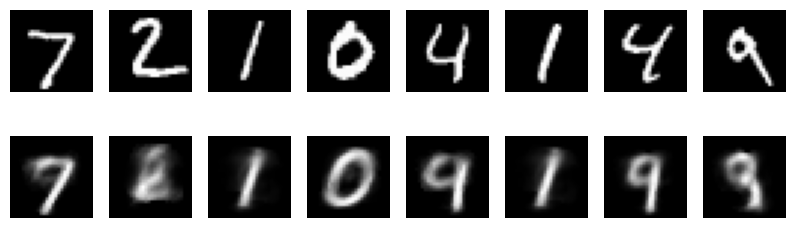

In [ ]:
model.eval()
x, _ = next(iter(test_loader))
x = x.to(device)

with torch.no_grad():
    x_recon = model(x)

# Plot
fig, axes = plt.subplots(2, 8, figsize=(10, 3))

for i in range(8):
    axes[0, i].imshow(x[i].cpu().squeeze(), cmap='gray')
    axes[1, i].imshow(x_recon[i].cpu().view(28,28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].axis('off')

plt.show()

**VAE**

Instead of having a latent representation (z) like in Autoencoders, Encoders of VAE gives mean, and log(variance). z can then be calculated using the following formula z = μ + σ * ε where ε ∼N(0,1)

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.fc_mu = nn.Linear(256, 2)
        self.fc_logvar = nn.Linear(256, 2)

        self.fc2 = nn.Linear(2, 256)
        self.fc3 = nn.Linear(256, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [ ]:
def vae_loss(x_recon, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(x_recon, x.view(-1, 784), reduction='sum')

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    total_loss = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)

        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.2f}")

Epoch 1, Loss: 25320.97
Epoch 2, Loss: 21759.55
Epoch 3, Loss: 21004.21
Epoch 4, Loss: 20704.05
Epoch 5, Loss: 20488.63
Epoch 6, Loss: 20322.82
Epoch 7, Loss: 20184.90
Epoch 8, Loss: 20078.94
Epoch 9, Loss: 19978.97
Epoch 10, Loss: 19898.27


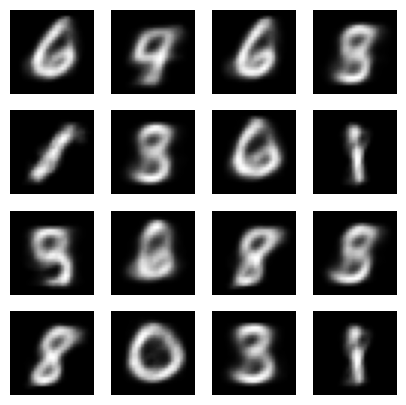

In [ ]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, 2).to(device)
    samples = model.decode(z).cpu()

fig, axes = plt.subplots(4, 4, figsize=(5,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i].view(28,28), cmap='gray')
    ax.axis('off')

plt.show()